In [4]:
!pip install numpy pandas matplotlib


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import files


In [6]:
uploaded = files.upload()


Saving model_metrics_conversational.csv to model_metrics_conversational.csv


In [8]:
df = pd.read_csv("model_metrics_conversational.csv")

models = df["Model"]
df = df.drop(columns=["Model"])

df.head()


,BLEU,ROUGE_L,BERTScore,Human_Score,Inference_Time,Model_Size
0,0.32,0.41,0.86,4.1,110,350
1,0.36,0.45,0.88,4.4,140,400
2,0.34,0.43,0.87,4.2,95,300
3,0.29,0.39,0.84,3.9,70,250
4,0.40,0.49,0.91,4.6,160,520


In [9]:
normalized_df = df / np.sqrt((df ** 2).sum())
normalized_df


,BLEU,ROUGE_L,BERTScore,Human_Score,Inference_Time,Model_Size
0,0.416006,0.421161,0.440904,0.431746,0.412170,0.416726
1,0.468006,0.462250,0.451157,0.463338,0.524580,0.476258
2,0.442006,0.441706,0.446031,0.442277,0.355965,0.357193
3,0.377005,0.400617,0.430650,0.410686,0.262290,0.297661
4,0.520007,0.503339,0.466538,0.484398,0.599520,0.619135


In [10]:
weights = np.array([
    0.15,  # BLEU
    0.15,  # ROUGE
    0.20,  # BERTScore
    0.25,  # Human evaluation
    0.15,  # Inference Time (cost)
    0.10   # Model Size (cost)
])


In [11]:
weighted_df = normalized_df * weights
weighted_df


,BLEU,ROUGE_L,BERTScore,Human_Score,Inference_Time,Model_Size
0,0.062401,0.063174,0.088181,0.107937,0.061826,0.041673
1,0.070201,0.069338,0.090231,0.115834,0.078687,0.047626
2,0.066301,0.066256,0.089206,0.110569,0.053395,0.035719
3,0.056551,0.060093,0.086130,0.102671,0.039344,0.029766
4,0.078001,0.075501,0.093308,0.121100,0.089928,0.061914


In [12]:
criteria_type = np.array([1, 1, 1, 1, 0, 0])


In [13]:
ideal_best = np.where(
    criteria_type == 1,
    weighted_df.max(),
    weighted_df.min()
)

ideal_worst = np.where(
    criteria_type == 1,
    weighted_df.min(),
    weighted_df.max()
)

ideal_best, ideal_worst


(array([0.07800105, 0.07550086, 0.09330757, 0.1210996 , 0.03934351,
        0.02976612]),
 array([0.05655076, 0.06009252, 0.08613007, 0.1026714 , 0.08992802,
        0.06191354]))

In [14]:
distance_best = np.sqrt(((weighted_df - ideal_best) ** 2).sum(axis=1))
distance_worst = np.sqrt(((weighted_df - ideal_worst) ** 2).sum(axis=1))


In [15]:
topsis_score = distance_worst / (distance_best + distance_worst)

df["TOPSIS_Score"] = topsis_score
df["Rank"] = df["TOPSIS_Score"].rank(ascending=False)

final_result = pd.concat([models, df], axis=1)
final_result = final_result.sort_values("Rank")

final_result


,Model,BLEU,ROUGE_L,BERTScore,Human_Score,Inference_Time,Model_Size,TOPSIS_Score,Rank
2,FLAN-T5,0.34,0.43,0.87,4.2,95,300,0.661472,1.0
3,BERT-Retrieval,0.29,0.39,0.84,3.9,70,250,0.644952,2.0
0,DialoGPT,0.32,0.41,0.86,4.1,110,350,0.503281,3.0
1,BlenderBot,0.36,0.45,0.88,4.4,140,400,0.386120,4.0
4,LLaMA2-chat,0.40,0.49,0.91,4.6,160,520,0.355048,5.0


In [16]:
os.makedirs("results", exist_ok=True)

final_result.to_csv("results/topsis_conversational_results.csv", index=False)

print("File saved successfully!")


File saved successfully!


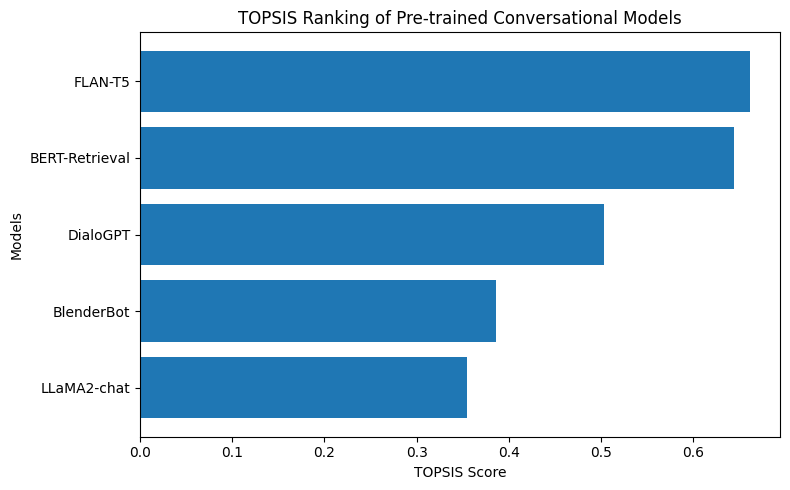

In [17]:
df_plot = pd.read_csv("results/topsis_conversational_results.csv")

plt.figure(figsize=(8,5))

plt.barh(df_plot["Model"], df_plot["TOPSIS_Score"])

plt.xlabel("TOPSIS Score")
plt.ylabel("Models")
plt.title("TOPSIS Ranking of Pre-trained Conversational Models")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("results/topsis_conversational_ranking.png", dpi=300)

plt.show()
